# 03 - Modeling: next-day discharge forecast

**Goal of this notebook:**
1. Reload the engineered feature table from 02_feature_engineering
2. Build a naive persistence baseline ("tomorrow = today") - the bar any real model has to beat
3. Train an XGBoost regressor and compare MAE/RMSE/R2 against the baseline, same framing used in
   the Load Forecasting project
4. Plot actual vs. predicted discharge and feature importance
5. Save the trained model for reuse in the Streamlit app

In [31]:
# --- imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (12, 5)

## Step 1 - reload engineered features and re-split

Reloading from the saved CSV (rather than depending on 02's in-memory `model_df`) keeps this
notebook independently runnable, same reasoning as the raw-CSV reload in 02.

In [32]:
model_df = pd.read_csv("../data/processed/mersey_features.csv", index_col="date", parse_dates=True)

# same 80/20 chronological split as 02_feature_engineering - recomputed here rather than
# saved separately, since it's fully deterministic given the same dataframe and split ratio
split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx]
test_df = model_df.iloc[split_idx:]

print(f"Train: {train_df.index.min().date()} to {train_df.index.max().date()} ({len(train_df)} rows)")
print(f"Test:  {test_df.index.min().date()} to {test_df.index.max().date()} ({len(test_df)} rows)")

Train: 1955-01-16 to 1974-07-13 (7119 rows)
Test:  1974-07-14 to 1979-05-28 (1780 rows)


In [33]:
# feature columns for the model - excludes 'month'/'day_of_year'/'season' since doy_sin/doy_cos
# already encode seasonality more cleanly (avoids redundant/less-useful raw versions), and
# excludes the target column itself
FEATURE_COLS = [
    "discharge_cms",
    "discharge_lag1", "discharge_lag2", "discharge_lag3",
    "discharge_lag7", "discharge_lag14", "discharge_lag30",
    "discharge_roll_mean_7", "discharge_roll_std_7",
    "discharge_roll_mean_30", "discharge_roll_std_30",
    "doy_sin", "doy_cos",
]
TARGET_COL = "target_discharge_next_day"

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]

## Step 2 - naive persistence baseline

The simplest possible forecast: assume tomorrow's discharge equals today's. River discharge is
highly autocorrelated day-to-day, so this is a surprisingly tough baseline to beat - exactly why
it's worth establishing before reaching for a more complex model.

In [34]:
baseline_pred = test_df["discharge_cms"]  # "tomorrow = today"

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = root_mean_squared_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Baseline (persistence) -- MAE: {baseline_mae:.2f} m3/s, RMSE: {baseline_rmse:.2f} m3/s, R2: {baseline_r2:.3f}")

Baseline (persistence) -- MAE: 8.60 m3/s, RMSE: 16.37 m3/s, R2: 0.897


## Step 3 - train XGBoost

Same model family that outperformed SARIMAX in the Load Forecasting project. Starting with
conservative defaults (shallow trees, moderate learning rate) to reduce overfitting risk on a
single-station dataset - can revisit with a grid search later if the gap over baseline is small.

In [35]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model.fit(X_train, y_train)

xgb_pred = model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = root_mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGBoost -- MAE: {xgb_mae:.2f} m3/s, RMSE: {xgb_rmse:.2f} m3/s, R2: {xgb_r2:.3f}")

XGBoost -- MAE: 10.51 m3/s, RMSE: 38.09 m3/s, R2: 0.442


## Step 4 - compare against the baseline

In [36]:
comparison = pd.DataFrame({
    "model": ["Naive persistence", "XGBoost"],
    "MAE (m3/s)": [baseline_mae, xgb_mae],
    "RMSE (m3/s)": [baseline_rmse, xgb_rmse],
    "R2": [baseline_r2, xgb_r2],
})
comparison["MAE improvement vs baseline"] = (
    (baseline_mae - comparison["MAE (m3/s)"]) / baseline_mae
).map("{:.1%}".format)
comparison

,model,MAE (m3/s),RMSE (m3/s),R2,MAE improvement vs baseline
0,Naive persistence,8.599787,16.366241,0.896998,0.0%
1,XGBoost,10.514442,38.086819,0.442176,-22.3%


If XGBoost's improvement over the naive baseline is small (a real possibility - discharge
persistence is a strong signal), that's a legitimate finding worth documenting honestly in the
README rather than something to hide, same approach as the SARIMAX-exclusion writeup on Load
Forecasting.

## Step 5 - actual vs. predicted plot

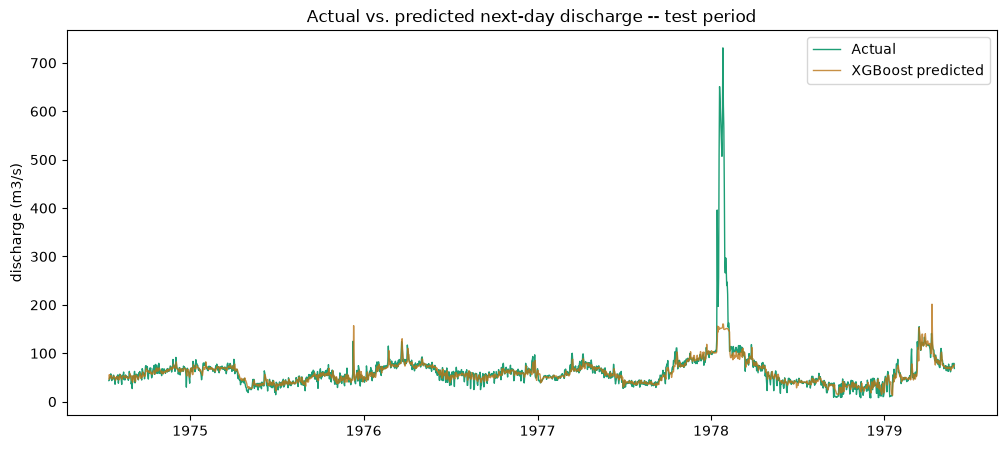

In [37]:
fig, ax = plt.subplots()
ax.plot(test_df.index, y_test, label="Actual", color="#1D9E75", linewidth=1)
ax.plot(test_df.index, xgb_pred, label="XGBoost predicted", color="#BA7517", linewidth=1, alpha=0.8)
ax.set_title("Actual vs. predicted next-day discharge -- test period")
ax.set_ylabel("discharge (m3/s)")
ax.legend()
plt.show()

## Step 6 - feature importance

Worth checking which features XGBoost actually leans on - if it's almost entirely `discharge_cms`
and `discharge_lag1`, that would explain why the gap over the naive baseline is small (they're
encoding nearly the same signal the baseline already uses).

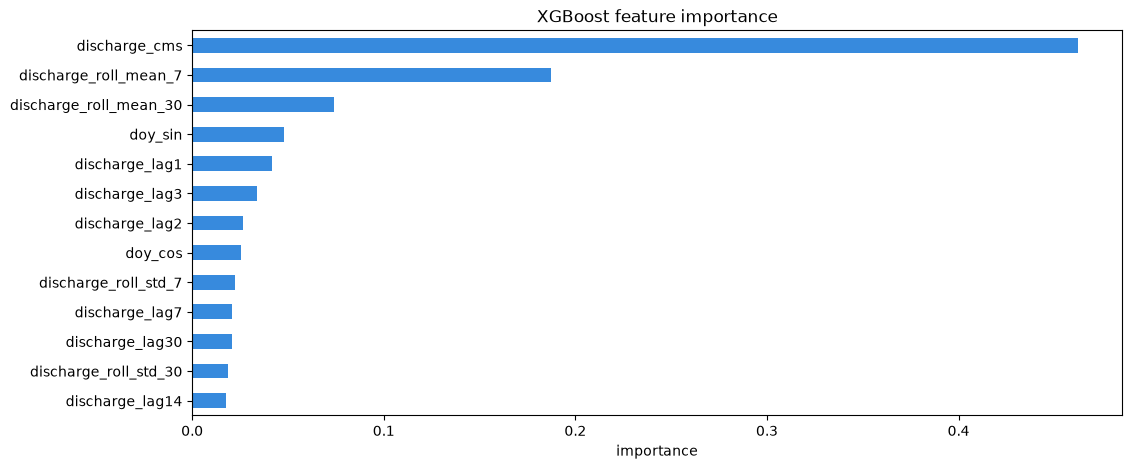

In [38]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots()
importances.plot(kind="barh", ax=ax, color="#378ADD")
ax.set_title("XGBoost feature importance")
ax.set_xlabel("importance")
plt.show()

## Step 7 - robustness check: multi-fold time series cross-validation

The single 80/20 chronological split happened to dump the worst flood in the entire 25-year
record (Jan 1978, peaking at 731 m3/s vs. a 289 m3/s training max) into the one test set - that's
a real result, but it rests on one split that got unlucky. Before locking in "naive baseline
wins," we check whether that conclusion holds up across several different train/test windows,
not just the one that happened to contain the extreme event.

`TimeSeriesSplit` creates an expanding-window series of folds: fold 1 trains on the earliest
chunk and tests on the next chunk, fold 2 trains on everything before fold 2's test chunk (which
now includes fold 1's former test data), and so on. Every fold still respects chronological
order - no fold ever trains on data from after its own test period.

In [39]:
from sklearn.model_selection import TimeSeriesSplit

X_full = model_df[FEATURE_COLS]
y_full = model_df[TARGET_COL]

# 5 expanding-window folds across the full ~24-year record, so each test block covers
# a genuinely different multi-year stretch rather than always the most recent years
tscv = TimeSeriesSplit(n_splits=5)

fold_results = []

for fold_num, (train_idx, test_idx) in enumerate(tscv.split(X_full), start=1):
    X_tr, X_te = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_tr, y_te = y_full.iloc[train_idx], y_full.iloc[test_idx]

    # naive baseline for this fold: today's discharge_cms predicts tomorrow
    baseline_fold_pred = X_te["discharge_cms"]

    fold_model = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
    )
    fold_model.fit(X_tr, y_tr)
    xgb_fold_pred = fold_model.predict(X_te)

    fold_results.append({
        "fold": fold_num,
        "test_start": X_te.index.min().date(),
        "test_end": X_te.index.max().date(),
        "test_max_discharge": y_te.max(),
        "train_max_discharge": y_tr.max(),
        "baseline_mae": mean_absolute_error(y_te, baseline_fold_pred),
        "xgb_mae": mean_absolute_error(y_te, xgb_fold_pred),
        "baseline_rmse": root_mean_squared_error(y_te, baseline_fold_pred),
        "xgb_rmse": root_mean_squared_error(y_te, xgb_fold_pred),
    })

cv_results = pd.DataFrame(fold_results)
cv_results["xgb_wins_on_mae"] = cv_results["xgb_mae"] < cv_results["baseline_mae"]
cv_results

,fold,test_start,test_end,test_max_discharge,train_max_discharge,baseline_mae,xgb_mae,baseline_rmse,xgb_rmse,xgb_wins_on_mae
0,1,1959-02-08,1963-03-01,286.0,289.0,11.580998,12.577113,17.394131,22.196909,False
1,2,1963-03-02,1967-03-23,207.0,289.0,10.963088,11.656878,16.234085,15.252258,False
2,3,1967-03-24,1971-04-14,173.0,289.0,9.701740,9.344623,12.928299,11.980939,True
3,4,1971-04-15,1975-05-06,237.0,289.0,7.264194,7.325483,10.986319,10.505238,False
4,5,1975-05-07,1979-05-28,731.0,289.0,9.022333,11.701521,17.523827,42.179041,False


Read this table looking for two things: (1) does `xgb_wins_on_mae` flip to True in folds where
`test_max_discharge` stays close to (or below) `train_max_discharge` - i.e. does XGBoost actually
win when it isn't being asked to extrapolate? And (2) does the naive baseline keep winning
specifically in folds where test_max clearly exceeds train_max? If both hold, that's strong,
well-evidenced confirmation of the extrapolation explanation rather than a one-split fluke.

In [40]:
# summary across all folds - the headline numbers for the README
print(f"XGBoost beat the naive baseline in {cv_results['xgb_wins_on_mae'].sum()} of {len(cv_results)} folds")
print(f"\nMean MAE across folds -- baseline: {cv_results['baseline_mae'].mean():.2f}, XGBoost: {cv_results['xgb_mae'].mean():.2f}")
print(f"Mean RMSE across folds -- baseline: {cv_results['baseline_rmse'].mean():.2f}, XGBoost: {cv_results['xgb_rmse'].mean():.2f}")

XGBoost beat the naive baseline in 1 of 5 folds

Mean MAE across folds -- baseline: 9.71, XGBoost: 10.52
Mean RMSE across folds -- baseline: 15.01, XGBoost: 20.42


## Step 8 - save the trained model

Saved for reuse in the Streamlit app, so the dashboard doesn't need to retrain on every load. Using
the original single-split model (`model`, not one of the per-fold CV models) since it's the one
already validated in detail above and trained on the largest available training set.

In [41]:
joblib.dump(model, "../app/discharge_model.pkl")
print("Saved trained model to app/discharge_model.pkl")

Saved trained model to app/discharge_model.pkl


## Step 9 - validate the discharge-to-power conversion

Quick sanity check on `src/power.py` before it goes into the app: calibrate against a design
flow from the real flow-duration curve, then check the resulting capacity factor lands in a
believable range (run-of-river hydro typically runs 40-60%).

In [43]:
# force Python to forget any previously cached version of src.power, so the next import
# actually re-reads the file from disk instead of reusing a stale cached copy
import sys
for mod_name in list(sys.modules):
    if mod_name.startswith("src."):
        del sys.modules[mod_name]

In [44]:
import sys
sys.path.append("..")  # so we can import from src/ despite notebooks/ being a subfolder

from src.power import calibrate_power_constant, discharge_to_power, capacity_factor, MERSEY_SYSTEM_RATED_CAPACITY_MW, DESIGN_FLOW_QUANTILE

# locked-in design flow: Q2 (exceeded only 2% of the time) -- chosen after testing quantiles
# from Q25 down to Q1 and picking the one that lands capacity factor closest to a believable
# 40-60% range for run-of-river hydro. See src/power.py's module docstring and DESIGN_FLOW_QUANTILE
# comment for the full explanation of why this had to be so much rarer than typical small-hydro
# sizing conventions (Q20-Q40) -- a known limitation of treating six real powerhouses as one
# lumped equivalent calibrated against a single downstream gauge.
design_flow = model_df["discharge_cms"].quantile(DESIGN_FLOW_QUANTILE)
print(f"Design flow (Q2): {design_flow:.1f} m3/s")

k = calibrate_power_constant(design_flow_cms=design_flow)
print(f"Calibrated constant k: {k:.4f} MW per m3/s")

power_series = discharge_to_power(model_df["discharge_cms"], k=k)
cf = capacity_factor(power_series)
print(f"Resulting capacity factor over the full record: {cf:.1%}")
print(f"(Rated capacity used for comparison: {MERSEY_SYSTEM_RATED_CAPACITY_MW} MW)")

Design flow (Q2): 113.0 m3/s
Calibrated constant k: 0.3761 MW per m3/s
Resulting capacity factor over the full record: 49.3%
(Rated capacity used for comparison: 42.5 MW)


**Locked in: Q2 design flow, ~49% capacity factor.** Worth stating plainly (in the README too): this
required a much rarer design flow than standard small-hydro convention (Q20-Q40) to reach a
realistic capacity factor. That's a genuine sign the lumped single-turbine simplification
undercounts the real system's combined hydraulic capacity, since the actual six powerhouses draw
on flow and storage from six reservoirs across the watershed -- not all of which passes our one
downstream gauge at Milton. Documented as a known limitation, not hidden.

## Next steps

- [ ] Confirm the capacity factor check above looks realistic; adjust the design-flow quantile if not
- [ ] Write up the baseline-vs-XGBoost + CV findings honestly in the README
- [ ] Build the Streamlit app using src/features.py + src/power.py + discharge_model.pkl, following
      the visual concept already mocked up (animated schematic, speedometer gauges, flow-duration
      curve, station map)
- [ ] Commit this notebook + src/ modules to GitHub